# SIGAP AI - Analysis Sentiment Model Building


### Import Library

In [1]:
# Common
import os
import re
import time
import pandas as pd

# Model
from sklearn.model_selection import train_test_split

# Preprocessing
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter


### Path Configuration


In [2]:
# KONFIGURASI PATH
BASE_DIR   = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "dataset")

DIPAWIDIA_PATH = os.path.join(DATA_DIR, "dipawidia_reviews.csv")
LAZADA_REVIEWS_PATH = os.path.join(DATA_DIR, "lazada_reviews.csv")
LAZADA_ITEMS_PATH   = os.path.join(DATA_DIR, "lazada_items.csv")
GMAPS_PATH = os.path.join(DATA_DIR, "gmaps_reviews.csv")
PRDECT_PATH = os.path.join(DATA_DIR, "prdect-id_reviews.csv")

### Basic Cleaning + Merge Dataset


In [3]:
# Basic Function

EMPTY_LIKE = {"", "null", "nan", "none"}

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.strip()
    if text.lower() in EMPTY_LIKE:
        return ""
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def extract_rating(value):
    value = str(value).strip()
    if re.fullmatch(r'[1-5](\.0)?', value):
        return int(float(value))
    return pd.NA

def clean_reviews_date(value):
    value = clean_text(value)
    return value if value else "unknown"


def first_non_empty(*values):
    for value in values:
        cleaned = clean_text(value)
        if cleaned:
            return cleaned
    return ""

def build_lazada_text(row):
    title = clean_text(row.get("reviewTitle", ""))
    content = clean_text(row.get("reviewContent", ""))

    if title and content:
        return f"{title}. {content}"
    return first_non_empty(content, title)

def build_googlemaps_text(row):
    return first_non_empty(row.get("text", ""), row.get("textTranslated", ""))

In [4]:
STANDARD_COLUMNS = [
    "Review_Text",
    "Review_Date",
    "Rating_Score",
    "Platform_Source",
    "Business_Category",
    "Dataset_Source",
    "Raw_Sentiment",
    "Raw_Category",
    "Raw_Id",
]

In [5]:
# Dipawidia 
def loadset_dipawidia():
    df_raw = pd.read_csv(DIPAWIDIA_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["review"].apply(clean_text),
        "Review_Date": "unknown",
        "Rating_Score": pd.NA,
        "Platform_Source": "Multi platform",
        "Business_Category": "Lainnya",
        "Dataset_Source": "Dipawidia",
        "Raw_Sentiment": df_raw["sentimen"].fillna(""),
        "Raw_Category": "",
        "Raw_Id": df_raw.index.astype(str),
    })

    return df[STANDARD_COLUMNS]

# Lazada
def loadset_lazada():
    df_reviews = pd.read_csv(LAZADA_REVIEWS_PATH, dtype=str, encoding="utf-8-sig").fillna("")
    df_items = pd.read_csv(LAZADA_ITEMS_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df_items = (
        df_items[["itemId", "name"]]
        .drop_duplicates(subset=["itemId"], keep="first")
        .rename(columns={"name": "Product_Name"})
    )

    df_raw = df_reviews.merge(df_items, on="itemId", how="left").fillna("")

    bought_date = df_raw["boughtDate"].apply(clean_reviews_date)
    retrieved_date = df_raw["retrievedDate"].apply(clean_reviews_date)

    df = pd.DataFrame({
        "Review_Text": df_raw.apply(build_lazada_text, axis=1),
        "Review_Date": bought_date.where(bought_date != "unknown", retrieved_date),
        "Rating_Score": df_raw["rating"].apply(extract_rating),
        "Platform_Source": "Lazada",
        "Business_Category": "Elektronik",
        "Dataset_Source": "Lazada",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["category"].fillna(""),
        "Raw_Id": df_raw["itemId"].astype(str) + "_" + df_raw.index.astype(str),
    })

    return df[STANDARD_COLUMNS]

# Google Maps
def loadset_googlemaps():
    df_raw = pd.read_csv(GMAPS_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    platform_source = df_raw["reviewOrigin"].replace("", "Google Maps")
    platform_source = platform_source.replace("Google", "Google Maps")

    raw_id = df_raw["reviewId"].replace("", pd.NA)
    fallback_id = pd.Series(df_raw.index.astype(str), index=df_raw.index)
    raw_id = raw_id.combine_first(fallback_id)

    df = pd.DataFrame({
        "Review_Text": df_raw.apply(build_googlemaps_text, axis=1),
        "Review_Date": df_raw["publishedAtDate"].apply(clean_reviews_date),
        "Rating_Score": df_raw["stars"].apply(extract_rating),
        "Platform_Source": platform_source,
        "Business_Category": "F&B",
        "Dataset_Source": "GoogleMaps",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["title"].fillna(""),
        "Raw_Id": raw_id.astype(str),
    })

    return df[STANDARD_COLUMNS]

# Prdect-ID
def loadset_prdect():
    df_raw = pd.read_csv(PRDECT_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["Customer Review"].apply(clean_text),
        "Review_Date": "unknown",
        "Rating_Score": df_raw["Customer Rating"].apply(extract_rating),
        "Platform_Source": "Tokopedia",
        "Business_Category": df_raw["Category"].fillna(""),
        "Dataset_Source": "PRDECT-ID",
        "Raw_Sentiment": df_raw["Sentiment"].fillna(""),
        "Raw_Category": df_raw["Category"].fillna(""),
        "Raw_Id": df_raw.index.astype(str),
    })

    return df[STANDARD_COLUMNS]

In [6]:
df_dipawidia = loadset_dipawidia()
df_lazada = loadset_lazada()
df_googlemaps = loadset_googlemaps()
df_prdect = loadset_prdect()

df_all = pd.concat([df_dipawidia, df_lazada, df_googlemaps, df_prdect], ignore_index=True)

### Data Exploration & Visualization

#### Exploration

In [7]:
print("Jumlah Data:", len(df_all))
print("\nKolom Dataset:")
print(df_all.columns.tolist())

display(df_all.head())

Jumlah Data: 231657

Kolom Dataset:
['Review_Text', 'Review_Date', 'Rating_Score', 'Platform_Source', 'Business_Category', 'Dataset_Source', 'Raw_Sentiment', 'Raw_Category', 'Raw_Id']


,Review_Text,Review_Date,Rating_Score,Platform_Source,Business_Category,Dataset_Source,Raw_Sentiment,Raw_Category,Raw_Id
0,Suara dan mic puas. Hanya saya pesan yg nyala ...,unknown,<NA>,Multi platform,Lainnya,Dipawidia,0,,0
1,Good. Mudah-mudahan awet. Makasih,unknown,<NA>,Multi platform,Lainnya,Dipawidia,1,,1
2,"kondisi dus robek2, tolong di perhatikan lagi",unknown,<NA>,Multi platform,Lainnya,Dipawidia,0,,2
3,Kualitas produk baik. Harga terjangkau dan pen...,unknown,<NA>,Multi platform,Lainnya,Dipawidia,0,,3
4,"Overall bagus, tombol berfungsi semuanya, tapi...",unknown,<NA>,Multi platform,Lainnya,Dipawidia,0,,4


In [8]:
df_all.shape

(231657, 9)

In [9]:
df_all.describe()

,Review_Text,Review_Date,Rating_Score,Platform_Source,Business_Category,Dataset_Source,Raw_Sentiment,Raw_Category,Raw_Id
count,231657,231657,220051,231657,231657,231657,231657,231657,231657
unique,62617,12556,5,4,32,4,5,51,226257
top,,unknown,5,Lazada,Elektronik,Lazada,,beli-harddisk-eksternal,0
freq,98013,17006,177006,203787,203787,203787,214651,82223,2


In [10]:
df_all.dtypes

Review_Text          object
Review_Date          object
Rating_Score         object
Platform_Source      object
Business_Category    object
Dataset_Source       object
Raw_Sentiment        object
Raw_Category         object
Raw_Id               object
dtype: object

In [11]:
df_all.isnull().sum()

Review_Text              0
Review_Date              0
Rating_Score         11606
Platform_Source          0
Business_Category        0
Dataset_Source           0
Raw_Sentiment            0
Raw_Category             0
Raw_Id                   0
dtype: int64

#### Visualization

In [12]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

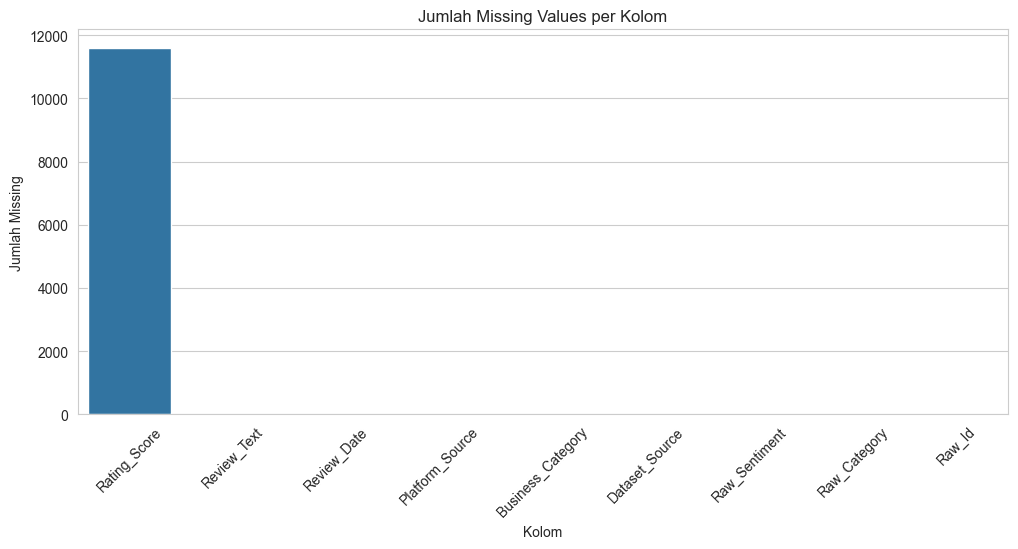

In [13]:
missing_values = df_all.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=missing_values.index,
    y=missing_values.values
)

plt.title("Jumlah Missing Values per Kolom")
plt.xticks(rotation=45)
plt.ylabel("Jumlah Missing")
plt.xlabel("Kolom")
plt.show()

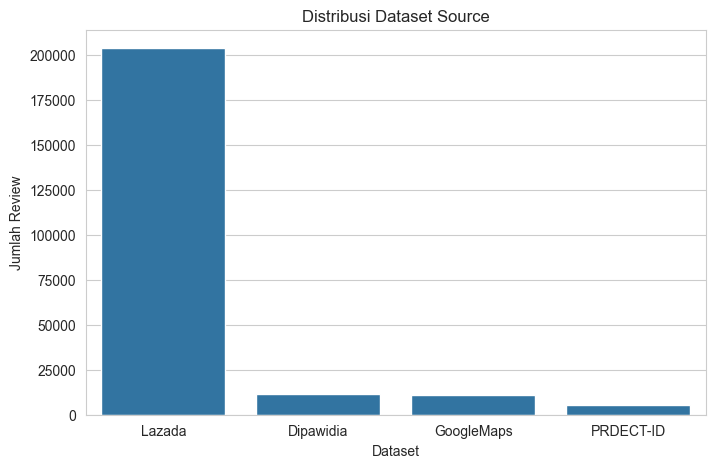

In [14]:
source_counts = df_all["Dataset_Source"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=source_counts.index,
    y=source_counts.values
)

plt.title("Distribusi Dataset Source")
plt.xlabel("Dataset")
plt.ylabel("Jumlah Review")
plt.show()

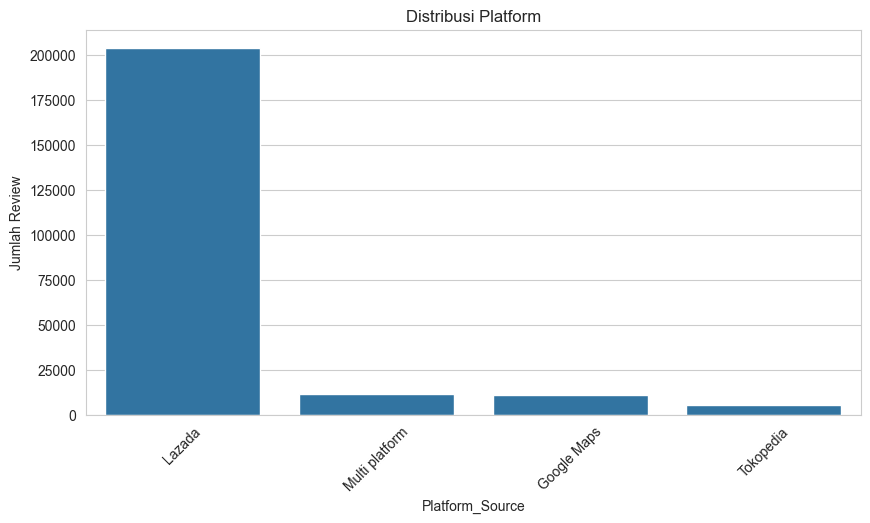

In [15]:
platform_counts = df_all["Platform_Source"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(
    x=platform_counts.index,
    y=platform_counts.values
)

plt.title("Distribusi Platform")
plt.xticks(rotation=45)
plt.ylabel("Jumlah Review")
plt.show()

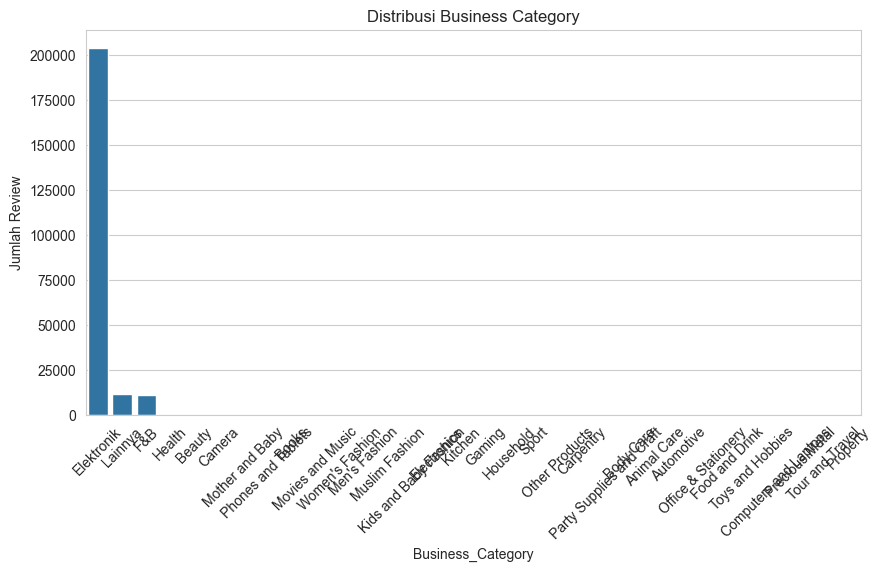

In [16]:
category_counts = df_all["Business_Category"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)

plt.title("Distribusi Business Category")
plt.xticks(rotation=45)
plt.ylabel("Jumlah Review")
plt.show()

In [17]:
rating_df = df_all.dropna(subset=["Rating_Score"]).copy()
rating_df["Rating_Score"] = rating_df["Rating_Score"].astype(int)

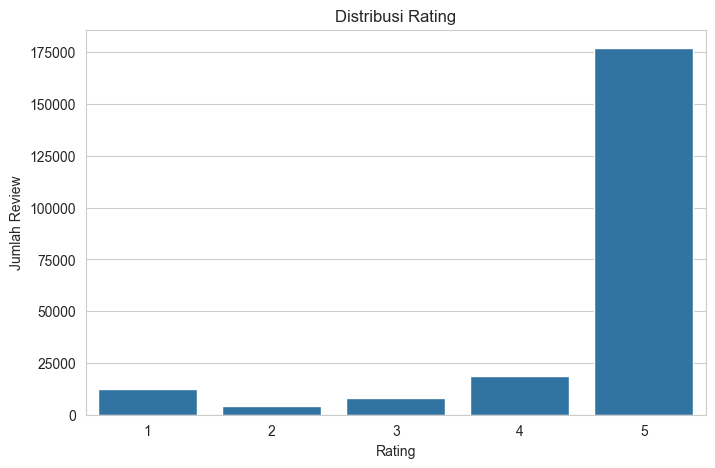

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="Rating_Score",
    data=rating_df
)

plt.title("Distribusi Rating")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.show()

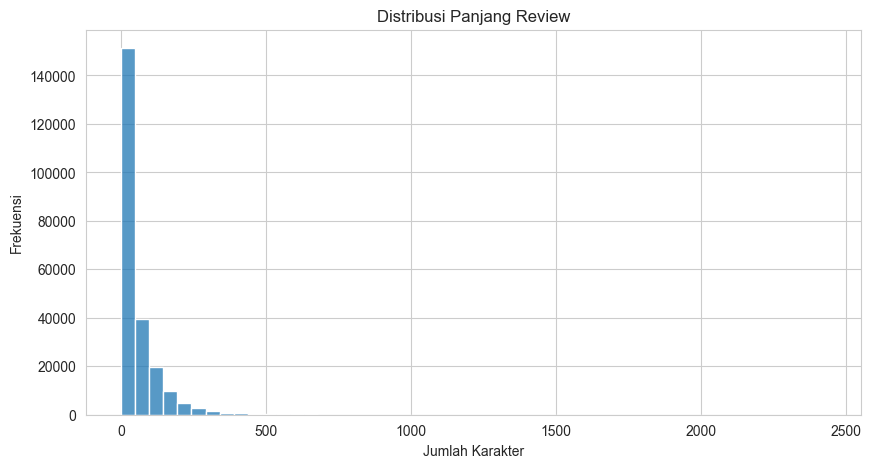

In [19]:
df_all["Review_Length"] = df_all["Review_Text"].str.len()

plt.figure(figsize=(10, 5))

sns.histplot(
    df_all["Review_Length"],
    bins=50
)

plt.title("Distribusi Panjang Review")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Frekuensi")
plt.show()

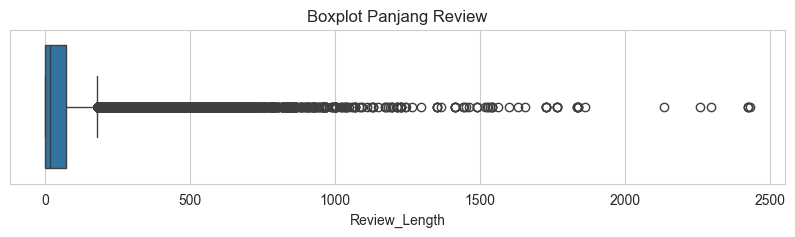

In [20]:
plt.figure(figsize=(10, 2))

sns.boxplot(
    x=df_all["Review_Length"]
)

plt.title("Boxplot Panjang Review")
plt.show()

In [21]:
duplicate_count = df_all.duplicated(subset=["Review_Text"]).sum()

print(f"Jumlah Duplicate Review: {duplicate_count}")
print(f"Persentase Duplicate: {(duplicate_count / len(df_all)) * 100:.2f}%")

Jumlah Duplicate Review: 169040
Persentase Duplicate: 72.97%


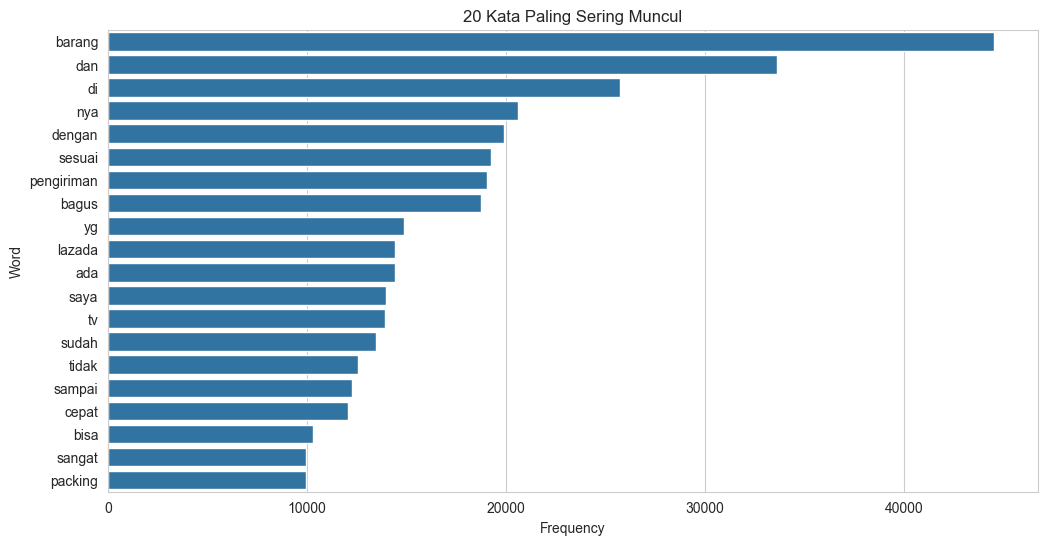

In [22]:
all_text = " ".join(df_all["Review_Text"].astype(str)).lower()

words = all_text.split()

word_freq = Counter(words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_words,
    x="Frequency",
    y="Word"
)

plt.title("20 Kata Paling Sering Muncul")
plt.show()

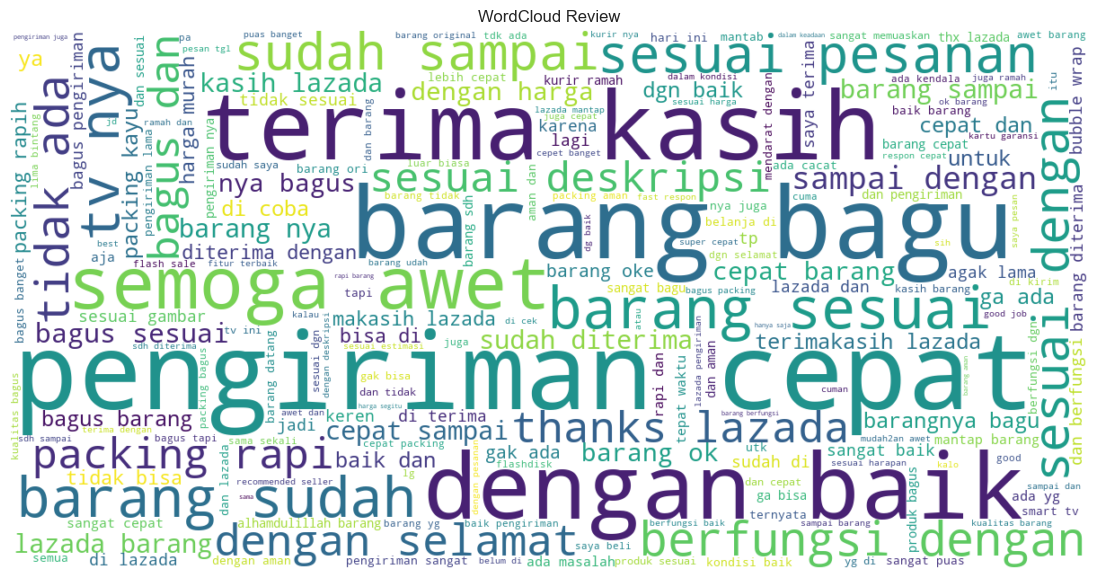

In [23]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Review")
plt.show()

In [24]:
df_all[[
    "Review_Text",
    "Dataset_Source",
    "Platform_Source",
    "Rating_Score"
]].sample(10)

,Review_Text,Dataset_Source,Platform_Source,Rating_Score
189733,"Not Bad. Flashdisk OK, bonus nya karatan :(",Lazada,Lazada,4
196304,,Lazada,Lazada,5
157914,barang bagus berfungsi dgn baik,Lazada,Lazada,5
221499,"Makanya enak enak, pelayanan ramah, penyajiann...",GoogleMaps,Google Maps,5
80454,maaf baru ngasih ulasann... tv berfungsi denga...,Lazada,Lazada,5
20647,,Lazada,Lazada,3
219391,,GoogleMaps,Google Maps,5
20283,Mantap. Produk bagus dan kualitas ok sekali bos,Lazada,Lazada,5
40966,,Lazada,Lazada,5
136399,,Lazada,Lazada,5


### Labeling

In [25]:
keyword_neutral = [
    'lumayan', 'biasa saja', 'biasa aja', 'cukup', 'standar', 'oke lah', 'okelah',
    'tidak buruk', 'tidak terlalu', 'bisa lah', 'bisalah', 'plus minus', 'sesuai harga',
    'masih oke', 'masih bisa', 'masih lumayan', 'belum tahu', 'belum tau']

keyword_rasa = [
    'rasa', 'enak', 'lezat', 'gurih', 'manis', 'asin', 'pahit', 'asam', 'nikmat', 'sedap',
    'hambar', 'segar', 'mantap', 'yummy', 'flavor', 'taste', 'bumbu', 'aroma', 'wangi',
    'harum', 'bau', 'pedas', 'crispy', 'renyah', 'tekstur', 'empuk', 'keras', 'lembut',
    'makanan', 'minuman', 'kopi', 'snack', 'matang', 'gosong', 'dingin', 'hangat', 'fresh',
    'juicy', 'creamy', 'aftertaste', 'porsi']

keyword_harga = [
    'harga', 'murah', 'mahal', 'worth', 'worthit', 'worth it', 'terjangkau', 'ekonomis',
    'hemat', 'diskon', 'promo', 'cashback', 'ongkir', 'gratis', 'sesuai harga',
    'overpriced', 'kemahalan', 'budget', 'biaya', 'bayar', 'tagihan', 'nominal', 'rupiah',
    'sebanding', 'tidak sebanding', 'mahal banget', 'murah meriah']

keyword_bentuk = [
    'bentuk', 'ukuran', 'kemasan', 'packaging', 'tampilan', 'desain', 'warna', 'model',
    'penampilan', 'fisik', 'material', 'bahan', 'kualitas', 'kokoh', 'kuat', 'rapuh',
    'tahan lama', 'awet', 'nyaman', 'pas', 'layar', 'body', 'casing', 'jahitan',
    'original', 'ori', 'asli', 'palsu', 'sesuai gambar', 'sesuai deskripsi', 'bagus',
    'jelek', 'rapi', 'bersih', 'kotor', 'besar', 'kecil', 'tipis', 'tebal', 'berat', 'ringan',
    'halus', 'kasar', 'lecet', 'penyok', 'retak', 'robek', 'pecah']

keyword_krisis = [
    'penipuan', 'tipu', 'bohong', 'palsu', 'rusak', 'cacat', 'hancur', 'kecewa',
    'tidak sesuai', 'tidak sama', 'berbeda', 'salah kirim', 'tidak sampai', 'hilang',
    'komplain', 'refund', 'return', 'retur', 'tidak berfungsi', 'tidak nyala', 'mati',
    'error', 'gagal', 'mengecewakan', 'parah', 'buruk', 'jangan beli', 'hindari',
    'barang tidak datang', 'barang hilang', 'pesanan tidak sesuai', 'uang tidak kembali',
    'tidak ori', 'lama banget', 'seller tidak merespon', 'pelayanan buruk', 'expired']

keyword_negasi = [
    'tidak', 'tak', 'bukan', 'belum', 'kurang', 'tanpa', 'gak', 'ga', 'nggak', 'ngga',
    'tdk', 'tp', 'tapi', 'namun', 'sayangnya', 'sayang']

keyword_sarcasm_positif = [
    'mantap', 'keren', 'jos', 'josss', 'perfect', 'sempurna', 'luar biasa', 'terbaik',
    'worth it', 'worthit', 'memuaskan', 'berkualitas', 'bintang lima', '5 bintang',
    'recommended banget', 'bagus banget', 'mantap banget', 'puas banget']

category_mapping_dataset_prdect = {
    'Food and Drink': 'F&B', 'Kitchen': 'F&B',
    'Computers and Laptops': 'Elektronik', 'Phones and Tablets': 'Elektronik',
    'Electronics': 'Elektronik', 'Camera': 'Elektronik', 'Gaming': 'Elektronik',
    "Women's Fashion": 'Fashion', "Men's Fashion": 'Fashion', 'Muslim Fashion': 'Fashion',
    'Kids and Baby Fashion': 'Fashion',
    'Health': 'Kesehatan & Kecantikan', 'Beauty': 'Kesehatan & Kecantikan',
    'Body Care': 'Kesehatan & Kecantikan',
    'Household': 'Perabotan', 'Carpentry': 'Perabotan',
    'Mother and Baby': 'Ibu & Bayi',
    'Animal Care': 'Perawatan Hewan',
    'Toys and Hobbies': 'Hobi & Hiburan', 'Movies and Music': 'Hobi & Hiburan',
    'Books': 'Hobi & Hiburan', 'Tour and Travel': 'Hobi & Hiburan', 'Sport': 'Hobi & Hiburan',
    'Automotive': 'Otomotif',
    'Office & Stationery': 'Perlengkapan Kantor',
    'Party Supplies and Craft': 'Kerajinan & Pesta',
    'Precious Metal': 'Lainnya', 'Property': 'Lainnya', 'Other Products': 'Lainnya'}


In [26]:
# LABELING DATA
LABELS = {'Positive', 'Negative', 'Neutral'}

RAW_SENTIMENT_MAP = {
    '0': 'Negative',
    '1': 'Positive',
    'positive': 'Positive',
    'positif': 'Positive',
    'negative': 'Negative',
    'negatif': 'Negative',
    'neutral': 'Neutral',
    'netral': 'Neutral',
}

def normalize_text(text):
    if not isinstance(text, str):
        return ''
    text = clean_text(text)
    return text.lower()


def contains_any(text, keywords):
    text = normalize_text(text)
    for kw in keywords:
        kw = normalize_text(kw)
        if kw and kw in text:
            return True
    return False


def to_int_rating(value):
    if pd.isna(value):
        return None
    try:
        return int(float(str(value).strip()))
    except Exception:
        return None


def normalize_label(label):
    label = normalize_text(label)
    return RAW_SENTIMENT_MAP.get(label, '')


def rating_to_sentiment(rating):
    if rating is None:
        return ''
    if rating in [1, 2]:
        return 'Negative'
    if rating == 3:
        return 'Neutral'
    if rating in [4, 5]:
        return 'Positive'
    return ''


def assign_sentiment(row):
    source = clean_text(row.get('Dataset_Source', ''))
    text = normalize_text(row.get('Review_Text', ''))
    raw_sentiment = normalize_label(row.get('Raw_Sentiment', ''))
    rating = to_int_rating(row.get('Rating_Score', None))

    if source == 'Dipawidia':
        if raw_sentiment in LABELS:
            return raw_sentiment
        if contains_any(text, keyword_neutral):
            return 'Neutral'
        sentiment_from_rating = rating_to_sentiment(rating)
        if sentiment_from_rating:
            return sentiment_from_rating
        return 'Neutral'

    sentiment_from_rating = rating_to_sentiment(rating)
    if sentiment_from_rating:
        return sentiment_from_rating

    if raw_sentiment in LABELS:
        return raw_sentiment

    return 'Neutral'


def assign_rating(row):
    rating = to_int_rating(row.get('Rating_Score', None))
    if rating is not None:
        return rating

    sentiment = normalize_label(row.get('Sentiment_Label', ''))
    if sentiment == 'Negative':
        return 2
    if sentiment == 'Neutral':
        return 3
    if sentiment == 'Positive':
        return 5

    return pd.NA


def detect_aspect(text):
    if not isinstance(text, str):
        return 'Lainnya'

    text_lower = normalize_text(text)

    scores = {
        'Rasa': sum(1 for kw in keyword_rasa if normalize_text(kw) in text_lower),
        'Harga': sum(1 for kw in keyword_harga if normalize_text(kw) in text_lower),
        'Bentuk': sum(1 for kw in keyword_bentuk if normalize_text(kw) in text_lower),
    }

    max_score = max(scores.values())

    if max_score == 0:
        return 'Lainnya'

    for aspect in ['Rasa', 'Harga', 'Bentuk']:
        if scores[aspect] == max_score:
            return aspect

    return 'Lainnya'


def assign_crisis(row):
    sentiment = normalize_label(row.get('Sentiment_Label', ''))
    rating = to_int_rating(row.get('Rating_Score', None))
    text = normalize_text(row.get('Review_Text', ''))

    is_negative = sentiment == 'Negative'
    is_low_rating = rating is not None and rating <= 2

    if (is_negative or is_low_rating) and contains_any(text, keyword_krisis):
        return 'Yes'
    return 'No'


def assign_business_category(row):
    source = clean_text(row.get('Dataset_Source', ''))
    raw_category = clean_text(row.get('Raw_Category', ''))
    current_category = clean_text(row.get('Business_Category', ''))

    if source == 'PRDECT-ID':
        return category_mapping_dataset_prdect.get(raw_category, 'Lainnya')

    return current_category if current_category else 'Lainnya'


def assign_sarcasm(row):
    if normalize_label(row.get('Sentiment_Label', '')) != 'Negative':
        return 'No'

    text = normalize_text(row.get('Review_Text', ''))
    if not text:
        return 'No'

    for keyword in keyword_sarcasm_positif:
        kw = normalize_text(keyword)
        if kw and kw in text:
            idx = text.find(kw)
            context_before = text[max(0, idx - 25):idx]
            if contains_any(context_before, keyword_negasi):
                return 'No'
            return 'Yes'

    return 'No'

In [27]:
def labeling_dataset(df):
    df = df.copy()

    required_cols = [
        "Review_Text",
        "Rating_Score",
        "Dataset_Source",
        "Business_Category",
        "Raw_Category",
        "Raw_Sentiment",
    ]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")
    
    if "Rating_Score_Original" not in df.columns:
        df["Rating_Score_Original"] = df["Rating_Score"]

    df["Sentiment_Label"] = df.apply(assign_sentiment, axis=1)

    df["Rating_Score"] = df.apply(assign_rating, axis=1)

    df["Review_Aspect"] = df["Review_Text"].apply(detect_aspect)

    df["Crisis_Flag"] = df.apply(assign_crisis, axis=1)

    df["Business_Category"] = df.apply(assign_business_category, axis=1)

    df["Is_Sarcasm"] = df.apply(assign_sarcasm, axis=1)

    return df

In [28]:
df_all_labeled = labeling_dataset(df_all)

print("\nSentiment distribution / Distribusi sentimen:")
sentiment_counts = df_all_labeled["Sentiment_Label"].value_counts(dropna=False)
for label, count in sentiment_counts.items():
    pct = (count / len(df_all_labeled)) * 100
    print(f"  {label:<10} : {count:>8,} ({pct:.1f}%)")


Sentiment distribution / Distribusi sentimen:
  Positive   :  201,442 (87.0%)
  Negative   :   22,276 (9.6%)
  Neutral    :    7,939 (3.4%)


### Data Splitting



In [29]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

df_train, df_test = train_test_split(
    df_all_labeled,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_all_labeled["Sentiment_Label"]
)

df_train = (df_train.reset_index(drop=True))
df_test = (df_test.reset_index(drop=True))

print(f"Data train : {len(df_train):,} baris")
print(f"Data test  : {len(df_test):,} baris")

Data train : 185,325 baris
Data test  : 46,332 baris


### Data Preprocessing

In [30]:
def cleaning_dataset(df):
    df = df.copy()
    info = {}

    info["total_awal_raw"] = len(df)
    before_cols = df.columns.tolist()

    # Normalisasi teks 
    df["Review_Text"] = df["Review_Text"].apply(clean_text)

    # Hapus review kosong
    mask_text_empty = df["Review_Text"].eq("")
    info["teks_kosong"] = int(mask_text_empty.sum())
    df = df.loc[~mask_text_empty].copy()

    # Data Rating Dipawidia dikeep
    mask_rating_valid = df["Rating_Score"].notna() | df["Dataset_Source"].eq("Dipawidia")
    info["hapus_rating"] = int((~mask_rating_valid).sum())
    df = df.loc[mask_rating_valid].copy()

    # Standardisasi tipe data rating
    if "Rating_Score" in df.columns:
        df["Rating_Score"] = pd.to_numeric(df["Rating_Score"], errors="coerce").astype("Int64")

    # Hapus duplikasi
    dup_subset = ["Review_Text", "Review_Date", "Rating_Score", "Platform_Source", "Dataset_Source"]
    before_dup = len(df)
    df = df.drop_duplicates(subset=dup_subset).copy()
    info["hapus_duplikat"] = before_dup - len(df)

    # Hapus review yang terlalu pendek
    before_short = len(df)
    mask_long_enough = df["Review_Text"].str.split().str.len().fillna(0).ge(2)
    df = df.loc[mask_long_enough].copy()
    info["hapus_pendek"] = before_short - len(df)

    df = df.reset_index(drop=True)

    info["total_akhir"] = len(df)
    info["total_noise"] = info["total_awal_raw"] - info["total_akhir"]
    info["noise_pct"] = round((info["total_noise"] / info["total_awal_raw"]) * 100, 2) if info["total_awal_raw"] else 100

    after_cols = df.columns.tolist()
    info["kolom_awal"] = before_cols
    info["kolom_akhir"] = after_cols
    info["kolom_baru"] = [c for c in after_cols if c not in before_cols]
    info["kolom_hilang"] = [c for c in before_cols if c not in after_cols]

    return df, info

In [31]:
slang_dict = {
    "yg": "yang", "dg": "dengan", "dgn": "dengan", "utk": "untuk",
    "tdk": "tidak", "gak": "tidak", "ga": "tidak", "nggak": "tidak",
    "ngga": "tidak", "gk": "tidak", "bgt": "banget", "bgtt": "banget",
    "tp": "tapi", "tpi": "tapi", "krn": "karena", "karna": "karena",
    "aja": "saja", "jg": "juga", "jd": "jadi", "sdh": "sudah",
    "udh": "sudah", "blm": "belum", "msh": "masih", "mksh": "terima kasih",
    "makasih": "terima kasih", "thanks": "terima kasih", "thx": "terima kasih",
    "recomend": "recommended", "rekomen": "recommended", "ori": "original",
    "mantap": "bagus", "keren": "bagus", "jos": "bagus"
}

preserve_terms = {
    "original", "palsu", "garansi", "refund", "return", "komplain",
    "diskon", "promo", "cashback", "ongkir", "packaging", "seller",
    "rating", "review", "baterai", "charger", "wifi", "bluetooth",
    "android", "gaming", "premium", "fashion", "enak", "lezat",
    "gurih", "renyah", "crispy", "manis", "pahit", "asam",
    "pedas", "asin", "empuk", "keras", "lembut", "murah",
    "mahal", "hemat", "cepat", "lambat", "rusak", "bagus",
    "buruk", "jelek", "puas", "kecewa", "hancur", "cacat",
    "tipu", "hilang", "error", "gagal"
}

custom_stopwords = {
    "wah", "wow", "hehe", "haha", "hihi", "dong", "nih", "sih", "deh", "lah",
    "ini", "itu", "sini", "sana", "saya", "aku", "kami", "kita", "mereka", "anda",
    "hari", "minggu", "bulan", "tahun", "jam", "menit", "kemarin", "sekarang", "nanti",
    "order", "pesan", "beli", "produk", "barang", "item", "paket", "dapat", "terima",
    "datang", "tiba", "sampai", "kirim", "dikirim", "foto", "gambar", "deskripsi"
}

important_negations = {"tidak", "tak", "bukan", "belum", "jangan", "gak", "ga", "nggak", "ngga", "tdk"}

factory_stop = StopWordRemoverFactory()
sastrawi_stop = set(factory_stop.get_stop_words())

all_stopwords = (sastrawi_stop | custom_stopwords) - important_negations

factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()


In [32]:
stem_cache = {}

def stem_cached(word):
    if word not in stem_cache:
        stem_cache[word] = stemmer.stem(word)
    return stem_cache[word]

def preprocess_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""

    URL_PATTERN = re.compile(r"http\S+|www\S+|https\S+")
    NON_ALNUM_PATTERN = re.compile(r"[^a-z0-9\s]")
    MULTISPACE_PATTERN = re.compile(r"\s+")
    NUMBER_PATTERN = re.compile(r"\b\d+\b")

    # Lowercase + hapus URL
    text = text.lower()
    text = URL_PATTERN.sub(" ", text)

    # Pertahankan huruf, angka, spasi
    text = NON_ALNUM_PATTERN.sub(" ", text)
    text = NUMBER_PATTERN.sub(" ", text)
    text = MULTISPACE_PATTERN.sub(" ", text).strip()

    tokens = text.split()

    # Slang normalization
    tokens = [slang_dict.get(tok, tok) for tok in tokens]

    cleaned_tokens = []
    for tok in tokens:
        if tok in all_stopwords:
            continue
        if len(tok) <= 1:
            continue

        # Simpan istilah penting
        if tok in preserve_terms:
            cleaned_tokens.append(tok)
        else:
            cleaned_tokens.append(stem_cached(tok))

    return re.sub(r"\s+", " ", " ".join(cleaned_tokens)).strip()


def preprocessing_dataset(df):
    df = df.copy()
    before_cols = df.columns.tolist()

    df["Review_Text_Processed"] = df["Review_Text"].apply(preprocess_text)

    # Hapus hasil proses yang kosong
    mask_non_empty = df["Review_Text_Processed"].astype(str).str.strip().ne("")
    removed_empty = int((~mask_non_empty).sum())
    df = df.loc[mask_non_empty].copy()

    df = df.reset_index(drop=True)

    after_cols = df.columns.tolist()
    col_info = {
        "kolom_awal": before_cols,
        "kolom_akhir": after_cols,
        "kolom_baru": [c for c in after_cols if c not in before_cols],
        "kolom_hilang": [c for c in before_cols if c not in after_cols],
    }

    return df, removed_empty, col_info


def print_column_change(info, title=""):
    if title:
        print(f"\n{title}")
    print(f"    Kolom awal  : {len(info['kolom_awal'])}")
    print(f"    Kolom akhir : {len(info['kolom_akhir'])}")
    print(f"    Kolom baru   : {info['kolom_baru']}")
    print(f"    Kolom hilang : {info['kolom_hilang']}")

In [33]:
df_train_clean, info_clean_train = cleaning_dataset(df_train)
df_test_clean, info_clean_test = cleaning_dataset(df_test)

print(f"    Train setelah cleaning : {len(df_train_clean):,} baris")
print(f"    Test setelah cleaning  : {len(df_test_clean):,} baris")
print(f"    Noise train            : {info_clean_train['noise_pct']}%")
print(f"    Noise test             : {info_clean_test['noise_pct']}%")

print_column_change(info_clean_train, title="[Train] Perubahan struktur kolom setelah cleaning")
print_column_change(info_clean_test, title="[Test] Perubahan struktur kolom setelah cleaning")

start_time = time.time()

df_train_final, empty_train, col_info_train = preprocessing_dataset(df_train_clean)
df_test_final, empty_test, col_info_test = preprocessing_dataset(df_test_clean)

elapsed = round(time.time() - start_time, 2)

print(f"    Train final                 : {len(df_train_final):,} baris")
print(f"    Test final                  : {len(df_test_final):,} baris")
print(f"    Baris kosong setelah proses  : {empty_train + empty_test:,}")
print(f"    Waktu proses preprocessing   : {elapsed} detik")

print_column_change(col_info_train, title="[Train] Perubahan struktur kolom setelah preprocessing")
print_column_change(col_info_test, title="[Test] Perubahan struktur kolom setelah preprocessing")

    Train setelah cleaning : 55,768 baris
    Test setelah cleaning  : 21,168 baris
    Noise train            : 69.91%
    Noise test             : 54.31%

[Train] Perubahan struktur kolom setelah cleaning
    Kolom awal  : 15
    Kolom akhir : 15
    Kolom baru   : []
    Kolom hilang : []

[Test] Perubahan struktur kolom setelah cleaning
    Kolom awal  : 15
    Kolom akhir : 15
    Kolom baru   : []
    Kolom hilang : []
    Train final                 : 55,644 baris
    Test final                  : 21,111 baris
    Baris kosong setelah proses  : 181
    Waktu proses preprocessing   : 2801.51 detik

[Train] Perubahan struktur kolom setelah preprocessing
    Kolom awal  : 15
    Kolom akhir : 16
    Kolom baru   : ['Review_Text_Processed']
    Kolom hilang : []

[Test] Perubahan struktur kolom setelah preprocessing
    Kolom awal  : 15
    Kolom akhir : 16
    Kolom baru   : ['Review_Text_Processed']
    Kolom hilang : []


In [34]:
FINAL_COLUMNS = [
    "Review_Text",
    "Review_Text_Processed",
    "Review_Date",
    "Rating_Score",
    "Platform_Source",
    "Business_Category",
    "Sentiment_Label",
    "Review_Aspect",
    "Crisis_Flag",
    "Is_Sarcasm"
]


In [36]:

df_train_final = df_train_final[FINAL_COLUMNS].copy()
df_test_final = df_test_final[FINAL_COLUMNS].copy()

print("\nDATASET TRAIN")
display(df_train_final.head())

print("\nDATASET TEST")
display(df_test_final.head())


DATASET TRAIN


,Review_Text,Review_Text_Processed,Review_Date,Rating_Score,Platform_Source,Business_Category,Sentiment_Label,Review_Aspect,Crisis_Flag,Is_Sarcasm
0,Cepat datang paket nya ... Kurir ramah Tp belo...,cepat nya kurir ramah bom coba capasity my to,07 Jan 2019,5,Lazada,Elektronik,Positive,Bentuk,No,No
1,"Brangnya oke, tapi selesnya klo di chat gk prn...",brangnya oke les klo chat tidak prnah dibales ...,unknown,2,Multi platform,Lainnya,Negative,Lainnya,No,No
2,"Kesini krn suami ngeyel pengen nyobain, 1. Bar...",kesini suami ngeyel ken nyobain baru dateng su...,2023-04-10T19:32:47.091Z,1,Google Maps,F&B,Negative,Rasa,No,No
3,Cs nya payah,cs nya payah,unknown,2,Multi platform,Lainnya,Negative,Lainnya,No,No
4,Bagus. Murah tp gk murahan. Terima kasih lazada,bagus murah tidak murah kasih lazada,11 Nov 2016,5,Lazada,Elektronik,Positive,Harga,No,No



DATASET TEST


,Review_Text,Review_Text_Processed,Review_Date,Rating_Score,Platform_Source,Business_Category,Sentiment_Label,Review_Aspect,Crisis_Flag,Is_Sarcasm
0,Meringankan kerja ibu2.. ga capek lagi angkat2...,ringan kerja ibu2 tidak capek angkat2 galon,unknown,2,Multi platform,Lainnya,Negative,Bentuk,No,No
1,good job... no complain,good job no complain,13 Jul 2018,3,Lazada,Elektronik,Neutral,Lainnya,No,No
2,Recommended Seller. Kualitas barang sangat bai...,recommended seller kualitas sangat baik packin...,24 Nov 2017,5,Lazada,Elektronik,Positive,Bentuk,No,No
3,ok banget cukup besar tv nya udah dicek Alhamd...,banget cukup besar tv nya udah cek alhamdulill...,05 Sep 2019,5,Lazada,Elektronik,Positive,Harga,No,No
4,"TVnya bagus, sesuai deskripsi, pengiriman juga...",tvnya bagus sesuai kirim cepat rumah terima ka...,27 Sep 2018,5,Lazada,Elektronik,Positive,Bentuk,No,No


In [39]:
OUTPUT_DIR = os.path.join(DATA_DIR, "processed-dataset")

os.makedirs(OUTPUT_DIR, exist_ok=True)

df_train_final.to_csv(os.path.join(OUTPUT_DIR, "train_final.csv"), index=False, encoding="utf-8-sig")
df_test_final.to_csv(os.path.join(OUTPUT_DIR, "test_final.csv"), index=False, encoding="utf-8-sig")